# Empirische Evaluation und statistische Analyse
**Forschungsprojekt:** Prototyp-Evaluierung eines KI-Sales-Agenten im E-Commerce  
**Autor:** Fabian Fürst  
**Datum:** Juni 2026  
**Datensatz:** SoSci-Umfrage-Export ($N = 68$ gültige Fälle)

---

Dieses Jupyter-Notebook enthält die vollständige quantitative Evaluierung und statistische Analyse für den empirischen Teil dieser Thesis. Das Hauptziel ist die Bewertung der Benutzerfreundlichkeit, Akzeptanz und Nutzermerkmale des entwickelten Prototyps.

Die Analyse ist chronologisch in folgende Schritte strukturiert:
1. Datenimport und -bereinigung: Einlesen der Rohdaten, Aussortieren unvollständiger Datensätze sowie die zeitbasierte Ausreißerbehandlung ($85 \rightarrow 66 \rightarrow 57$).
2. Skalentransformationen: Methodische Vorbereitung der Messinstrumente (Umpolen des negativen TAEG-S-Items, SUS-Score-Transformation von 0 bis 100 und dimensionsbezogene TAM-Aggregation).
3. Globale deskriptive Statistik: Berechnung von Mittelwert ($\bar{x}$), Median ($\tilde{x}$) und Standardabweichung ($s$) für alle Kernmetriken der Gesamtstichprobe ($N = 57$).
4. Subgruppenanalyse: Durchführung des Median-Splits auf Basis des TAEG-S-Gesamtwerts zur Segmentierung und zum deskriptiven Vergleich der Nutzergruppen (geringere vs. höhere Technikaffinität).
5. Datenvisualisierung: Generierung publikationsreifer Boxplots und Diagramme (z. B. Verteilung der Bearbeitungszeit, SUS-Scores nach Nutzergruppe), die direkt für die Thesis exportiert werden.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 1. Datenimport und -bereinigung

In [2]:
from pathlib import Path

csv_path = Path("..") / "data" / "data_usability-akzeptanz-sales-agent.csv"
df = pd.read_csv(csv_path, encoding="utf-16")
df.head()

,CASE,SERIAL,REF,QUESTNNR,MODE,STARTED,DE01_01,DE02,DE03_01,DE04,...,MAILSENT,LASTDATA,STATUS,FINISHED,Q_VIEWER,LASTPAGE,MAXPAGE,MISSING,MISSREL,TIME_RSI
0,Interview-Nummer (fortlaufend),Personenkennung oder Teilnahmecode (sofern ver...,Referenz (sofern im Link angegeben),"Fragebogen, der im Interview verwendet wurde",Interview-Modus,Zeitpunkt zu dem das Interview begonnen hat (E...,Alter: ... Jahre,Geschlecht,Affinität Shopping: [Keine Beschreibung] 01,Endgerät,...,Versandzeitpunkt der Einladungsmail (nur für n...,Zeitpunkt als der Datensatz das letzte mal geä...,Status des Interviews (Markierung),Wurde die Befragung abgeschlossen (letzte Seit...,Hat der Teilnehmer den Fragebogen nur angesehe...,"Seite, die der Teilnehmer zuletzt bearbeitet hat","Letzte Seite, die im Fragebogen bearbeitet wurde",Anteil fehlender Antworten in Prozent,Anteil fehlender Antworten (gewichtet nach Rel...,Ausfüll-Geschwindigkeit (relativ)
1,34,NaN,NaN,base,interview,2026-06-04 20:20:59,26,2,5,1,...,NaN,2026-06-04 20:29:03,complete,1,0,7,7,0,0,1.09
2,36,NaN,NaN,base,interview,2026-06-04 20:35:57,66,1,5,2,...,NaN,2026-06-04 20:43:22,complete,1,0,7,7,0,0,1.04
3,37,NaN,NaN,base,interview,2026-06-04 20:36:00,63,2,5,2,...,NaN,2026-06-04 21:03:43,complete,1,0,7,7,0,0,0.37
4,39,NaN,NaN,base,interview,2026-06-04 20:42:36,23,2,5,2,...,NaN,2026-06-04 20:54:28,complete,1,0,7,7,0,0,0.73


In [3]:
# Drop columns that only contain metadata or are empty after the first row
empty_after_first_row = df.iloc[1:].isna().all(axis=0)
df = df.loc[:, ~empty_after_first_row]
df = df.drop(columns=["CASE", "QUESTNNR", "MODE", "RG01_CP", "LASTPAGE", "MAXPAGE", "MISSING", "MISSREL"])
df.head()

,STARTED,DE01_01,DE02,DE03_01,DE04,EI02,RG01,SU01_01,SU01_02,SU01_03,...,TIME004,TIME005,TIME006,TIME007,TIME_SUM,LASTDATA,STATUS,FINISHED,Q_VIEWER,TIME_RSI
0,Zeitpunkt zu dem das Interview begonnen hat (E...,Alter: ... Jahre,Geschlecht,Affinität Shopping: [Keine Beschreibung] 01,Endgerät,Consent,Zufallsgenerator Szenario: Gezogener Code,"System Usability Scale (SUS): Ich denke, dass ...",System Usability Scale (SUS): Ich fand das Sys...,System Usability Scale (SUS): Ich fand das Sys...,...,Verweildauer Seite 4,Verweildauer Seite 5,Verweildauer Seite 6,Verweildauer Seite 7,Verweildauer gesamt (ohne Ausreißer),Zeitpunkt als der Datensatz das letzte mal geä...,Status des Interviews (Markierung),Wurde die Befragung abgeschlossen (letzte Seit...,Hat der Teilnehmer den Fragebogen nur angesehe...,Ausfüll-Geschwindigkeit (relativ)
1,2026-06-04 20:20:59,26,2,5,1,1,2,5,5,5,...,113,214,49,30,484,2026-06-04 20:29:03,complete,1,0,1.09
2,2026-06-04 20:35:57,66,1,5,2,1,1,4,2,4,...,80,163,71,39,445,2026-06-04 20:43:22,complete,1,0,1.04
3,2026-06-04 20:36:00,63,2,5,2,1,2,5,1,1,...,255,882,261,64,1434,2026-06-04 21:03:43,complete,1,0,0.37
4,2026-06-04 20:42:36,23,2,5,2,1,2,5,1,5,...,140,352,82,39,712,2026-06-04 20:54:28,complete,1,0,0.73


In [4]:
# Only use rows where STATUS == 'complete'
df = df[df['STATUS'].fillna('').str.strip().str.lower() == 'complete'].reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 46 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   STARTED   66 non-null     str  
 1   DE01_01   63 non-null     str  
 2   DE02      66 non-null     str  
 3   DE03_01   66 non-null     str  
 4   DE04      66 non-null     str  
 5   EI02      66 non-null     str  
 6   RG01      66 non-null     str  
 7   SU01_01   66 non-null     str  
 8   SU01_02   66 non-null     str  
 9   SU01_03   66 non-null     str  
 10  SU01_04   66 non-null     str  
 11  SU01_05   66 non-null     str  
 12  SU01_06   66 non-null     str  
 13  SU01_07   66 non-null     str  
 14  SU01_08   66 non-null     str  
 15  SU01_09   66 non-null     str  
 16  SU01_10   66 non-null     str  
 17  SZ03      66 non-null     str  
 18  SZ03_01   66 non-null     str  
 19  SZ04      66 non-null     str  
 20  SZ04_01   66 non-null     str  
 21  SZ05      66 non-null     str  
 22  SZ06      66 no

In [5]:
cols_to_int = [
    "DE01_01", "DE02", "DE03_01", "DE04", "EI02", "RG01",
    "SU01_01", "SU01_02", "SU01_03", "SU01_04", "SU01_05",
    "SU01_06", "SU01_07", "SU01_08", "SU01_09", "SU01_10",
    "SZ03_01", "SZ04_01", "SZ05", "SZ06",
    "TA01_01", "TA01_02", "TA01_03", "TA01_04", "TA01_05", "TA01_06",
    "TG01_01", "TG01_02", "TG01_03", "TG01_04"
]

# numerische Spalten
df[cols_to_int] = df[cols_to_int].apply(pd.to_numeric, errors="coerce").astype("Int64")

df[cols_to_int].head()

,DE01_01,DE02,DE03_01,DE04,EI02,RG01,SU01_01,SU01_02,SU01_03,SU01_04,...,TA01_01,TA01_02,TA01_03,TA01_04,TA01_05,TA01_06,TG01_01,TG01_02,TG01_03,TG01_04
0,26,2,5,1,1,2,5,5,5,1,...,5,5,5,5,5,5,3,4,3,1
1,66,1,5,2,1,1,4,2,4,1,...,5,4,4,5,5,4,3,4,3,3
2,63,2,5,2,1,2,5,1,1,1,...,5,5,5,5,5,5,2,5,3,3
3,23,2,5,2,1,2,5,1,5,1,...,5,5,5,5,5,5,4,5,1,5
4,29,1,4,2,1,1,3,2,4,1,...,4,4,3,4,4,5,5,4,3,4


In [6]:
# STARTED und LASTDATA in datetime umwandeln
df["STARTED_dt"] = pd.to_datetime(df["STARTED"], errors="coerce")
df["LASTDATA_dt"] = pd.to_datetime(df["LASTDATA"], errors="coerce")

# Bearbeitungszeit berechnen
df["Bearbeitungszeit_min"] = (df["LASTDATA_dt"] - df["STARTED_dt"]).dt.total_seconds() / 60

pd.isna(df["Bearbeitungszeit_min"]).sum()

np.int64(0)

In [7]:
# Kennwerte berechnen
bearbeitungszeit = df["Bearbeitungszeit_min"]

median = bearbeitungszeit.median()
q1 = bearbeitungszeit.quantile(0.25)
q3 = bearbeitungszeit.quantile(0.75)
minimum = bearbeitungszeit.min()
maximum = bearbeitungszeit.max()

print("Bearbeitungszeit (in Minuten):")
print(f"Median: {median:.2f}")
print(f"Unteres Quartil (Q1): {q1:.2f}")
print(f"Oberes Quartil (Q3): {q3:.2f}")
print(f"Minimum: {minimum:.2f}")
print(f"Maximum: {maximum:.2f}")

Bearbeitungszeit (in Minuten):
Median: 11.60
Unteres Quartil (Q1): 7.28
Oberes Quartil (Q3): 15.77
Minimum: 1.10
Maximum: 466.95


In [8]:
# Filter für Bearbeitungszeit auf Basis von Median und IQR
bearbeitungszeit = df["Bearbeitungszeit_min"]

q1 = bearbeitungszeit.quantile(0.25)
q3 = bearbeitungszeit.quantile(0.75)
iqr = q3 - q1
median = bearbeitungszeit.median()

untergrenze = median * 0.40
obergrenze = q3 + 1.5 * iqr

valid_time_mask = bearbeitungszeit.between(untergrenze, obergrenze, inclusive="both")
removed_rows = (~valid_time_mask).sum()

print("Grenzen für die Bearbeitungszeit (in Minuten):")
print(f"Median: {median:.2f}")
print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Untergrenze (40 % des Medians): {untergrenze:.2f}")
print(f"Obergrenze (Q3 + 1,5 * IQR): {obergrenze:.2f}")
print(f"Entfernte Zeilen: {removed_rows}")

# Nur plausible Fälle behalten
df = df.loc[valid_time_mask].reset_index(drop=True)
bearbeitungszeit = df["Bearbeitungszeit_min"]
print(f"Verbleibende Zeilen: {len(df)}")

Grenzen für die Bearbeitungszeit (in Minuten):
Median: 11.60
Q1: 7.28
Q3: 15.77
IQR: 8.49
Untergrenze (40 % des Medians): 4.64
Obergrenze (Q3 + 1,5 * IQR): 28.50
Entfernte Zeilen: 9
Verbleibende Zeilen: 57


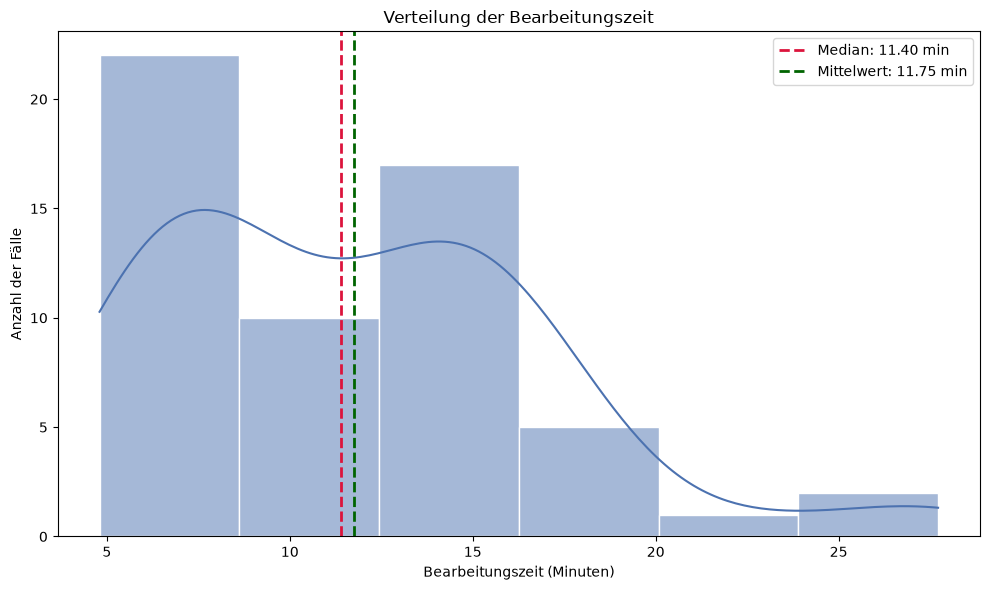

In [9]:
# Verteilung der Bearbeitungszeit in Minuten
plt.figure(figsize=(10, 6))

sns.histplot(
    bearbeitungszeit,
    bins="fd",
    kde=True,
    color="#4C72B0",
    edgecolor="white"
)

plt.axvline(bearbeitungszeit.median(), color="crimson", linestyle="--", linewidth=2, label=f"Median: {bearbeitungszeit.median():.2f} min")
plt.axvline(bearbeitungszeit.mean(), color="darkgreen", linestyle="--", linewidth=2, label=f"Mittelwert: {bearbeitungszeit.mean():.2f} min")

plt.title("Verteilung der Bearbeitungszeit")
plt.xlabel("Bearbeitungszeit (Minuten)")
plt.ylabel("Anzahl der Fälle")
plt.legend()
plt.tight_layout()
plt.show()

DE01_01 ist die Altersangabe und dementsprechend zu vernachlässigen.

## 2. Skalentransformation

### TAEG: Invertierung und Score-Berechnung

In [10]:
# Das negative Item invertieren (aus 1 wird 5, aus 2 wird 4 etc.)
df["TG01_01_reversed"] = 6 - pd.to_numeric(df["TG01_01"], errors="coerce")

# Liste der korrekten Items definieren
taeg_items = ['TG01_01_reversed', 'TG01_02', 'TG01_03', 'TG01_04']

# Zeilenmittelwert berechnen
df['TAEG_S_Score'] = df[taeg_items].mean(axis=1)

print("NaNs: "+str(pd.isna(df["TG01_01_reversed"]).sum()))
display(df['TAEG_S_Score'].head())

NaNs: 0


0    2.75
1    3.25
2    3.75
3    3.25
4     3.0
Name: TAEG_S_Score, dtype: Float64

### SUS: Berechnung des Gesamtwerts

In [11]:
# Erstellen eines df nur mit den SUS-Items,um die Reihenfolge der Transformation zu erleichtern
sus_items = [
    "SU01_01", "SU01_02", "SU01_03", "SU01_04", "SU01_05",
    "SU01_06", "SU01_07", "SU01_08", "SU01_09", "SU01_10"
]

for item in sus_items:
    df[item] = pd.to_numeric(df[item], errors='coerce')

sus_transformed = pd.DataFrame(index=df.index)

# Die mathematische Transformation nach John Brooke anwenden
for idx, item in enumerate(sus_items, start=1):
    if idx % 2 != 0:
        # Ungerade Items (1, 3, 5, 7, 9): Wert - 1
        sus_transformed[item] = df[item] - 1
    else:
        # Gerade Items (2, 4, 6, 8, 10): 5 - Wert
        sus_transformed[item] = 5 - df[item]

# Summe berechnen und mit 2,5 multiplizieren für den finalen Score (0 bis 100)
df['SUS_Score'] = sus_transformed.sum(axis=1) * 2.5

display(df[['SUS_Score']].head())

,SUS_Score
0,85.0
1,77.5
2,80.0
3,100.0
4,77.5


### TAM: AGGREGATION DER TAM-DIMENSIONEN (PU & PEOU)

In [15]:
# Definition der Items nach theoretischer Zuordnung
tam_pu_items = ['TA01_01', 'TA01_02']
tam_peou_items = ['TA01_04', 'TA01_05', 'TA01_06']

# Sicherstellen, dass alle Werte als Zahlen formatiert sind
all_tam_items = [f'TA01_{i:02d}' for i in range(1, 7)]
for item in all_tam_items:
    df[item] = pd.to_numeric(df[item], errors='coerce')

# Berechnung der Dimensionen als arithmetischer Mittelwert pro Zeile
df['TAM_PU'] = df[tam_pu_items].mean(axis=1)
df['TAM_PEOU'] = df[tam_peou_items].mean(axis=1)

# Das Item [03] direkt als eigene Kernmetrik (Nutzungsintention) abspeichern
df['TAM_BI'] = df['TA01_03']

# Erste Zeilen zur Kontrolle ausgeben
print("Die ersten berechneten TAM-Scores:")
display(df[['TAM_PU', 'TAM_PEOU', 'TAM_BI']].head())

Die ersten berechneten TAM-Scores:


,TAM_PU,TAM_PEOU,TAM_BI
0,5.0,5.0,5
1,4.5,4.666667,4
2,5.0,5.0,5
3,5.0,5.0,5
4,4.0,4.333333,3


## 3. Globale deskriptive Statistik

In [ ]:
# Definition aller berechneten Kernmetriken
core_metrics = ['TAEG_S_Score', 'SUS_Score', 'TAM_PU', 'TAM_PEOU', 'TAM_BI']

# Berechnung von Mittelwert, Median und Standardabweichung
global_stats = df[core_metrics].describe().loc[['mean', '50%', 'std']]

# Zeilen für die wissenschaftliche Berichterstattung sauber umbenennen
global_stats.index = ['Arithmetischer Mittelwert (x̄)', 'Median (x̃)', 'Standardabweichung (s)']

# Spaltennamen für die Anzeige lesbarer machen
global_stats.columns = [
    'Technikaffinität (TAEG-S)', 
    'System Usability (SUS)', 
    'Wahrgenommene Nützlichkeit (TAM_PU)', 
    'Bedienungsfreundlichkeit (TAM_PEOU)', 
    'Nutzungsintention (TAM_BI)'
]

# Ergebnisse gerundet auf 2 Nachkommastellen anzeigen
print("Globale deskriptive Kennwerte der Gesamtstichprobe (N = 57):")
display(global_stats.round(2))

In [12]:
# Deskriptive Kennwerte für den Text berechnen
taeg_mean = df['TAEG_S_Score'].mean()
taeg_median = df['TAEG_S_Score'].median()
taeg_std = df['TAEG_S_Score'].std()

print(f"Deskriptive Kennwerte des TAEG-S (N = {len(df)}):")
print(f"Arithmetischer Mittelwert (x̄): {taeg_mean:.2f}")
print(f"Median (x̃): {taeg_median:.2f}")
print(f"Standardabweichung (s): {taeg_std:.2f}\n")

Deskriptive Kennwerte des TAEG-S (N = 57):
Arithmetischer Mittelwert (x̄): 3.55
Median (x̃): 3.50
Standardabweichung (s): 0.54



In [13]:
# Median-Split durchführen
df['Technikaffinitaet_Gruppe'] = np.where(
    df['TAEG_S_Score'] <= taeg_median, 
    'Geringere Affinität', 
    'Höhere Affinität'
)
# Verteilung der Gruppen kontrollieren
print("Gruppenverteilung nach Median-Split:")
print(df['Technikaffinitaet_Gruppe'].value_counts())

Gruppenverteilung nach Median-Split:
Technikaffinitaet_Gruppe
Geringere Affinität    31
Höhere Affinität       26
Name: count, dtype: int64


### Interpretation der TAEG-S-Stichprobeneigenschaften
Die Stichprobe ($N = 57$) zeigt ein solides Grundinteresse und Verständnis für Technologie mit einem Mittelwert von $\bar{x} = 3,55$ ($s = 0,54$) auf einer fünfstufigen Likert-Skala. Der Stichprobenmedian liegt bei $\tilde{x} = 3,50$. 

Ein Median-Split ($\le 3,50$ vs. $> 3,50$) wurde erfolgreich durchgeführt, um zwei distinct Benutzergruppen für weitere Subgruppenanalysen zu etablieren:
* **Niedrige/mittlere Technikaffinität:** $n = 31$ Teilnehmer
* **Hohe Technikaffinität:** $n = 26$ Teilnehmer

Die geringe Unausgeglichenheit zwischen den Gruppengrößen ($31$ vs. $26$) ist ein mathematisch normales Phänomen beim Median-Split auf diskreten, niedrig-itemierten Likert-Skalen, da mehrere Teilnehmer das genaue Medianscore von $3,50$ teilen und strukturell der Unten-oder-gleich-Kategorie zugeordnet werden. Dieser Split wird nun als strukturelle Basis zur Querverweisung zwischen Benutzerfreundlichkeit (SUS) und Benutzerakzeptanz (TAM) dienen.

## 4. Subgruppenanalyse

## 5. Datenvisualisierung